# Validating kinGEMs Pipeline on $E. coli$ iML1515 Model

This notebook validates the metabolic flux predictions ecGEMs constructed with kinGEMs against experiemntal flux data. 

The experimental data comes from the study of Crown et al. (2015). It corresponds to measured metabolic fluxes using 13C metabolic flux analysis (13C-MFA). The studied organism was a W3110 strain of *E. coli*, grown on M9 media.

---
S. B. Crown, C. P. Long, and M. R. Antoniewicz, “Integrated 13 C-metabolic flux analysis of 14 parallel labeling experiments in Escherichia coli,” Metabolic Engineering, vol. 28, pp. 151–158, Jan. 2015, doi: 10.1016/j.ymben.2015.01.001.



In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Packages
import os
import sys
import pandas as pd 
import matplotlib.pyplot as plt 
import cobra 
import numpy as np 
from datetime import datetime
import cobra as cb
import random

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import process_kcat_predictions, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.fluxomics_validation import compare_fluxomics, apply_ecomics_condition
from kinGEMs.plots import plot_flux_correlation, plot_flux_differences

c:\Users\lyachinas\miniconda3\envs\kingems\Lib\site-packages\bioservices\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-09-22 16:05:56.723 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\lyachinas\OneDrive - University of Toronto\GitHub\kinGEMs_v2


In [2]:
# Directories
experimental_data_dir = os.path.join("../data", "experimental")
results_dir = os.path.join(os.getcwd(), "results")


In [3]:
experiment = 'W3110_MD121_M9+Glu_none'
experimental_fluxes_path = os.path.join(experimental_data_dir, f"fluxes_{experiment}.csv")

run_id = 'ecoli_iML1515_20250826_4941'
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id, "df_FBA.csv")

exp_validation_df = compare_fluxomics(fba_results_path=tuning_results_dir, 
                                      exp_fluxes_path=experimental_fluxes_path)

Loaded 2712 FBA flux results
Loaded 143 experimental flux measurements
Merged dataframe has 2712 rows
Matched reactions: 143
Unmatched reactions: 2569


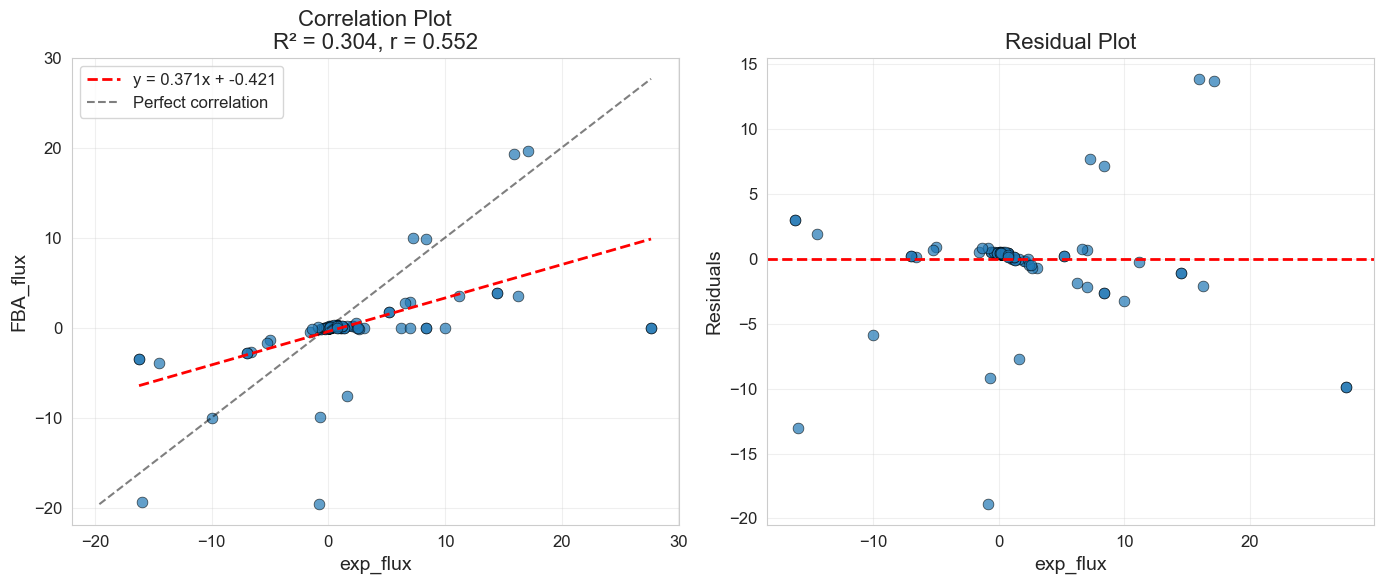

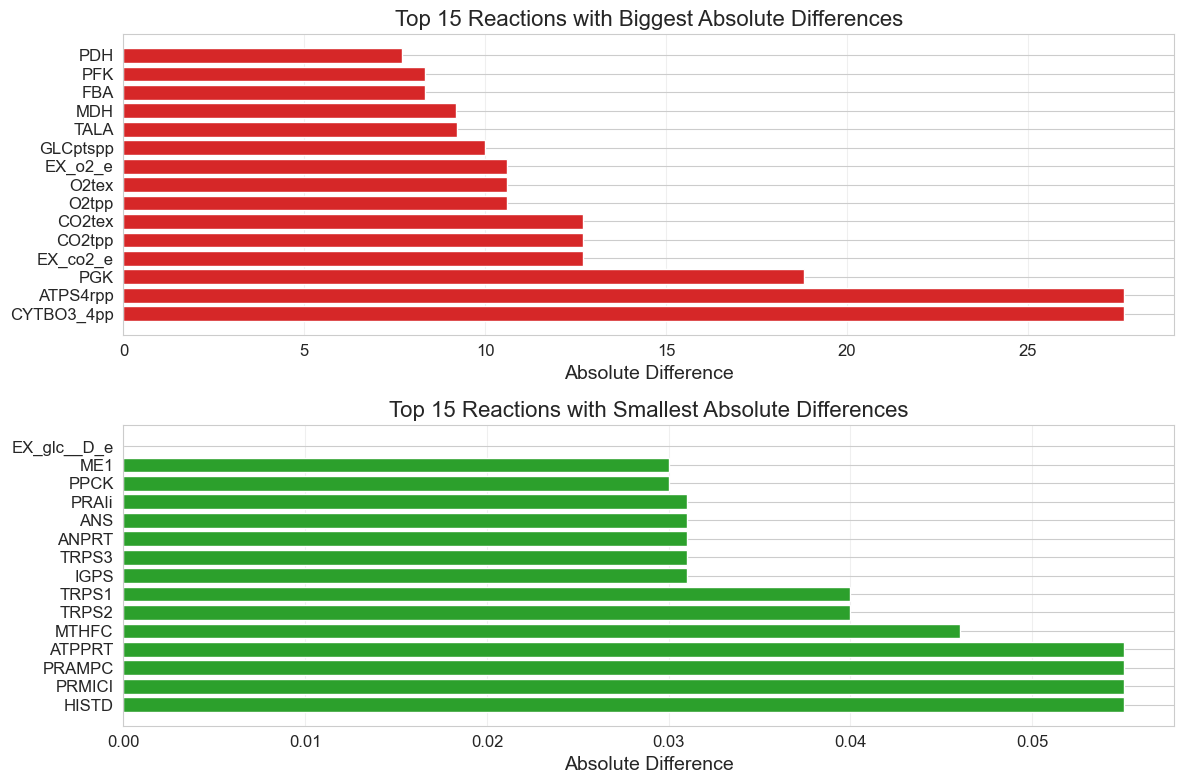

In [4]:
# Correlation plot
fig, results = plot_flux_correlation(exp_validation_df, 'exp_flux', 'FBA_flux', 
                                    output_path=None, show=True)

# Difference analysis
fig, diff_data = plot_flux_differences(exp_validation_df, 'exp_flux', 'FBA_flux', top_n=15, 
                                      difference_type='absolute', show=True)

## Set configuration

In [5]:
# Organism 
organism = "ecoli" # Update this
GEMname = "iML1515" # Update this 
run_id = f"{organism}_{GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Experiment ID
experiment = 'W3110_MD121_M9+Glu_none' # Update this

# Directories
experimental_data_dir = os.path.join("../data", "experimental")
processed_data_dir = os.path.join("../data", "processed")
results_dir = os.path.join(os.getcwd(), "results")
validation_results_dir = os.path.join(results_dir, "exp_validation_results", experiment)
#interim_data_dir = os.path.join("../data", "interim")

# Paths to files
model_path = os.path.join("../models", f"{GEMname}_GEM.xml")
processed_data_csv = os.path.join(processed_data_dir, f"{organism}_{GEMname}", f"{organism}_{GEMname}_processed_data.csv")
experimental_fluxes_csv = os.path.join(experimental_data_dir, f"fluxes_{experiment}.csv")
#merged_data_csv = os.path.join(interim_data_dir, f"{organism}_{GEMname}", f"{organism}_{GEMname}_merged_data.csv")
#predictions_csv = os.path.join(interim_data_dir, "CPI-Pred predictions", f"X06A_kinGEMs_{organism}_{GEMname}_predictions.csv")

# Load processed data
processed_data = pd.read_csv(processed_data_csv)

# Read model
model = cb.io.read_sbml_model(model_path)

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M'
enzyme_upper_bound = 0.15

## Run optimization with modified model

The GEM's lower bounds are modified to match the experimental uptake and secretion rates.

In [6]:
print("=== Step 1: Apply medium changes to model ===")

mod_model = apply_ecomics_condition(model=model, 
                                    medium_id='MD121', 
                                    stress='none')

=== Step 1: Apply medium changes to model ===
Applying M9+Glu medium
Set EX_glc__D_e lower bound to -10
Set EX_so4_e lower bound to -1.699
Set EX_o2_e lower bound to -14.49
Set EX_co2_e lower bound to 16.22


In [7]:
print("=== Step 2: Process CPI-Pred kcat values & annotate model ===")
mod_annotated_model = annotate_model_with_kcat_and_gpr(
    model=mod_model,
    df=processed_data
)


=== Step 2: Process CPI-Pred kcat values & annotate model ===


In [8]:
# Check FBA --> should be aroung 0.67 with mods
solution_model = mod_annotated_model.optimize()
print(f'Solution for annotated: {solution_model}')


Solution for annotated: <Solution 0.676 at 0x2ac9ea6b8c0>


In [9]:
# Check annotatations for kcat
for reaction in mod_annotated_model.reactions:
    print(reaction.annotation)

{'sbo': 'SBO:0000375', 'bigg.reaction': 'ALATA_D2', 'biocyc': 'META:RXN0-5240', 'kegg.reaction': 'R01147', 'metanetx.reaction': 'MNXR95697', 'rhea': ['28562', '28563', '28564', '28565'], 'gpr': 'AND/OR', 'kcat': [15514.873914775264, 13897.994967052622, 13897.994967052622, 2651.1748799330658, 6519.808480857254, 6519.808480857254], 'gpr_replaced': '(15514.9 or 13898 or 13898) or (2651.17 or 6519.81 or 6519.81)'}
{'sbo': 'SBO:0000375', 'bigg.reaction': 'SHCHD2', 'biocyc': 'META:DIMETHUROPORDEHYDROG-RXN', 'ec-code': '1.3.1.76', 'kegg.reaction': 'R03947', 'metanetx.reaction': 'MNXR104373', 'rhea': ['15613', '15614', '15615', '15616'], 'gpr': '1', 'kcat': [17834.980644884177, 12140.552112071453], 'gpr_replaced': '(17835 or 12140.6)'}
{'sbo': 'SBO:0000375', 'bigg.reaction': 'CPPPGO', 'biocyc': 'META:RXN0-1461', 'ec-code': '1.3.3.3', 'kegg.reaction': 'R03220', 'metanetx.reaction': 'MNXR96880', 'rhea': ['18257', '18258', '18259', '18260'], 'gpr': '1', 'kcat': [4876.592881249688, 12794.905598124

In [10]:
print("=== Step 3: Run optimization with kcat constraints ===")
(solution_value, df_FBA, gene_sequences_dict, _)=run_optimization_with_dataframe(
    model=mod_annotated_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True)


print("Biomass value: ", solution_value)

=== Step 3: Run optimization with kcat constraints ===
WARNING (W1002): Setting Var 'v[DMQMT]' to a numeric value
`-3.6781152339835125e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OHPHM]' to a numeric value
`-3.6781152339835125e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OMBZLM]' to a numeric value
`-3.678115233983512e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OMMBLHX3]' to a numeric value
`-3.678115233983512e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'v[OMPHHXy]' to a numeric value
`-3.6781152339835125e-15` outside the bounds (0.0, 1000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1